# Recommender Systems Assignment
## Content-Based Filtering using MovieLens Dataset

This notebook implements a content-based movie recommender system using the MovieLens dataset.
We use TF-IDF vectorization on movie genres and cosine similarity to recommend similar movies.

In [2]:
!pip install scikit-learn pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

movies.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Train size:", train_ratings.shape)
print("Test size:", test_ratings.shape)

Train size: (80668, 4)
Test size: (20168, 4)


In [6]:
data = pd.merge(train_ratings, movies, on="movieId")

data.head()

,userId,movieId,rating,timestamp,title,genres
0,509,7347,3.0,1435994597,Secret Window (2004),Mystery|Thriller
1,326,71462,4.0,1322252335,"Cove, The (2009)",Documentary
2,57,2115,3.0,965798155,Indiana Jones and the Temple of Doom (1984),Action|Adventure|Fantasy
3,610,1127,4.0,1479544102,"Abyss, The (1989)",Action|Adventure|Sci-Fi|Thriller
4,462,2409,2.0,1174438249,Rocky II (1979),Action|Drama


In [7]:
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


#Creating TF-IDF Matrix

In [8]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (9742, 23)


#Computing Cosine Similarity

In [9]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (9742, 9742)


In [10]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

indices.head()

,0
title,
Toy Story (1995),0
Jumanji (1995),1
Grumpier Old Men (1995),2
Waiting to Exhale (1995),3
Father of the Bride Part II (1995),4


In [11]:
def recommend_movies(title, top_n=5):

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]

    result = movies[['title']].iloc[movie_indices].copy()

    result['similarity_score'] = [i[1] for i in sim_scores]

    return result

In [12]:
recommend_movies("Toy Story (1995)")

,title,similarity_score
1706,Antz (1998),1.0
2355,Toy Story 2 (1999),1.0
2809,"Adventures of Rocky and Bullwinkle, The (2000)",1.0
3000,"Emperor's New Groove, The (2000)",1.0
3568,"Monsters, Inc. (2001)",1.0


In [13]:
def build_user_profile(user_id):

    user_movies = data[data['userId'] == user_id]

    movie_indices = user_movies['movieId'].map(
        dict(zip(movies.movieId, movies.index))
    ).dropna().astype(int)

    user_ratings = user_movies['rating'].values

    movie_vectors = tfidf_matrix[movie_indices]

    weighted_vectors = movie_vectors.multiply(user_ratings[:, np.newaxis])

    user_profile = weighted_vectors.sum(axis=0) / user_ratings.sum()

    user_profile = np.asarray(user_profile)

    return user_profile

In [14]:
def get_user_liked_movies(user_id):

    liked = ratings[
        (ratings['userId'] == user_id) &
        (ratings['rating'] >= 4)
    ]

    return liked['movieId'].tolist()

In [15]:
def recommend_for_user(user_id, top_n=5):

    liked_movies = get_user_liked_movies(user_id)

    scores = np.zeros(len(movies))

    for movie_id in liked_movies:

        idx = movies[movies['movieId'] == movie_id].index

        if len(idx) == 0:
            continue

        idx = idx[0]

        scores += cosine_sim[idx]

    top_indices = scores.argsort()[::-1][:top_n]

    return movies.iloc[top_indices][['movieId','title']]

In [16]:
recommend_for_user(1)

,movieId,title
8597,117646,Dragonheart 2: A New Beginning (2000)
4005,5657,Flashback (1990)
4681,6990,The Great Train Robbery (1978)
6570,55116,"Hunting Party, The (2007)"
3608,4956,"Stunt Man, The (1980)"


In [17]:
def get_relevant_movies(user_id):

    user_movies = ratings[
        (ratings['userId'] == user_id) &
        (ratings['rating'] >= 4)
    ]

    return set(user_movies['movieId'])

In [18]:
def get_relevant_movies(user_id):

    user_test = test_ratings[
        (test_ratings['userId'] == user_id) &
        (test_ratings['rating'] >= 3.5)
    ]

    return set(user_test['movieId'])

In [19]:
def precision_at_k(user_id, k=50):

    recommended = recommend_for_user(user_id, k)['movieId']

    relevant = set(get_user_liked_movies(user_id))

    hits = len(set(recommended) & relevant)

    return hits / k

In [20]:
def recall_at_k(user_id, k=50):

    recommended = recommend_for_user(user_id, k)['movieId']

    relevant = set(get_user_liked_movies(user_id))

    hits = len(set(recommended) & relevant)

    if len(relevant) == 0:
        return 0

    return hits / len(relevant)

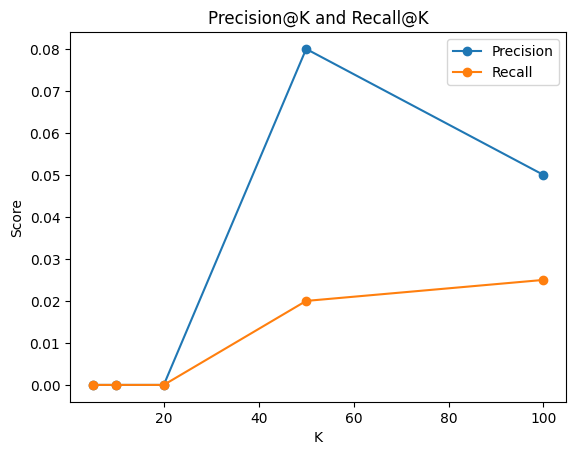

In [21]:
k_values = [5,10,20,50,100]

precision_scores = []
recall_scores = []

for k in k_values:

    precision_scores.append(precision_at_k(1,k))
    recall_scores.append(recall_at_k(1,k))

plt.plot(k_values, precision_scores, marker='o', label='Precision')
plt.plot(k_values, recall_scores, marker='o', label='Recall')

plt.xlabel("K")
plt.ylabel("Score")
plt.title("Precision@K and Recall@K")
plt.legend()
plt.show()

#Task 3- User-Based Collaborative Filtering


#Step 1- Create User-Movie Matrix

In [22]:
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Step 2- Fill Missing Values

In [23]:
user_movie_matrix_filled = user_movie_matrix.fillna(0)

#Step 3 - Compute User Similarity

In [24]:

from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_movie_matrix_filled)

print(user_similarity.shape)

(610, 610)


#Step 4 - Convert to DataFrame

In [25]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


#Step 5 - Find Similar Users

In [26]:
similar_users = user_similarity_df[1].sort_values(ascending=False)

similar_users.head(10)

,1
userId,
1,1.000000
266,0.357408
313,0.351562
368,0.345127
57,0.345034
91,0.334727
469,0.330664
39,0.329782
288,0.329700


#Step 6 – Predict Ratings

In [27]:
def predict_rating(user_id, movie_id):

    similar_users = user_similarity_df[user_id]

    movie_ratings = user_movie_matrix[movie_id]

    mask = movie_ratings.notna()

    similar_users = similar_users[mask]

    movie_ratings = movie_ratings[mask]

    if similar_users.sum() == 0:
        return 0

    prediction = np.dot(similar_users, movie_ratings) / similar_users.sum()

    return prediction

#Step 7 – Predict Ratings for Unseen Movies

In [28]:
def recommend_user_based(user_id, top_n=5):

    user_ratings = user_movie_matrix.loc[user_id]

    unseen_movies = user_ratings[user_ratings.isna()].index

    predictions = []

    for movie in unseen_movies:

        predicted_rating = predict_rating(user_id, movie)

        predictions.append((movie, predicted_rating))

    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)

    top_movies = predictions[:top_n]

    movie_ids = [m[0] for m in top_movies]

    return movies[movies['movieId'].isin(movie_ids)][['movieId','title']]

#Step 8 - Test Recommender

In [29]:
recommend_user_based(1,5)

,movieId,title
48,53,Lamerica (1994)
4045,5746,Galaxy of Terror (Quest) (1981)
4590,6818,Come and See (Idi i smotri) (1985)
4595,6835,Alien Contamination (1980)
5906,33649,Saving Face (2004)


#Step 9 – RMSE Evaluation

In [30]:
from sklearn.metrics import mean_squared_error
from math import sqrt

actual = []
predicted = []

for row in ratings.itertuples():

    user = row.userId
    movie = row.movieId
    rating = row.rating

    if movie in user_movie_matrix.columns:

        pred = predict_rating(user, movie)

        actual.append(rating)
        predicted.append(pred)

rmse = sqrt(mean_squared_error(actual, predicted))

print("RMSE:", rmse)

RMSE: 0.757315729470437


#Task 4- Item-Based Collaborative Filtering

In [31]:
item_user_matrix = user_movie_matrix.T

item_user_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
item_user_matrix_filled = item_user_matrix.fillna(0)

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(item_user_matrix_filled)

print(item_similarity.shape)

(9724, 9724)


In [34]:
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762,0.376316,0.277491,0.131629,0.232586,0.395573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.410562,1.000000,0.282438,0.106415,0.287795,0.297009,0.228576,0.172498,0.044835,0.417693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.296917,0.282438,1.000000,0.092406,0.417802,0.284257,0.402831,0.313434,0.304840,0.242954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035573,0.106415,0.092406,1.000000,0.188376,0.089685,0.275035,0.158022,0.000000,0.095598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.308762,0.287795,0.417802,0.188376,1.000000,0.298969,0.474002,0.283523,0.335058,0.218061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
item_similarity_df[1]

,1
movieId,
1,1.000000
2,0.410562
3,0.296917
4,0.035573
5,0.308762
...,...
193581,0.000000
193583,0.000000
193585,0.000000


In [36]:
def predict_rating_item_based(user_id, movie_id):

    user_ratings = user_movie_matrix.loc[user_id]

    similar_movies = item_similarity_df[movie_id]

    mask = user_ratings.notna()

    similar_movies = similar_movies[mask]
    user_ratings = user_ratings[mask]

    if similar_movies.sum() == 0:
        return 0

    prediction = np.dot(similar_movies, user_ratings) / similar_movies.sum()

    return prediction

In [37]:
def recommend_item_based(user_id, top_n=5):

    user_ratings = user_movie_matrix.loc[user_id]

    unseen_movies = user_ratings[user_ratings.isna()].index

    predictions = []

    for movie in unseen_movies:

        pred = predict_rating_item_based(user_id, movie)

        predictions.append((movie, pred))

    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)

    top_movies = predictions[:top_n]

    movie_ids = [m[0] for m in top_movies]

    return movies[movies['movieId'].isin(movie_ids)][['movieId','title']]

In [38]:
recommend_item_based(1,5)

,movieId,title
865,1140,Entertaining Angels: The Dorothy Day Story (1996)
1156,1519,Broken English (1996)
2179,2896,Alvarez Kelly (1966)
2348,3106,Come See the Paradise (1990)
2909,3899,Circus (2000)


In [39]:
actual = []
predicted = []

for row in ratings.itertuples():

    user = row.userId
    movie = row.movieId
    rating = row.rating

    if movie in item_similarity_df.columns:

        pred = predict_rating_item_based(user, movie)

        actual.append(rating)
        predicted.append(pred)

rmse_item = sqrt(mean_squared_error(actual, predicted))

print("Item-Based CF RMSE:", rmse_item)

Item-Based CF RMSE: 0.8892766910449942


#Task 5 - Implementing SVD for Recommndations

In [40]:
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from math import sqrt

In [41]:
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
R = user_movie_matrix.values

In [43]:
user_mean = np.nanmean(R, axis=1)

In [44]:
R_centered = R - user_mean.reshape(-1,1)

In [45]:
R_centered = np.nan_to_num(R_centered)

In [46]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20, random_state=42)

U = svd.fit_transform(R_centered)

Sigma = svd.singular_values_

Vt = svd.components_

In [47]:
print(U.shape)
print(Vt.shape)

(610, 20)
(20, 9724)


In [48]:
Sigma = np.diag(Sigma)

In [49]:
R_pred = np.dot(np.dot(U, Sigma), Vt)

In [50]:
R_pred = R_pred + user_mean.reshape(-1,1)

In [51]:
preds_df = pd.DataFrame(
    R_pred,
    columns=user_movie_matrix.columns,
    index=user_movie_matrix.index
)

In [52]:
preds_df = preds_df.clip(lower=0.5, upper=5)

In [53]:
def recommend_movies_svd(user_id, top_n=5):

    user_predictions = preds_df.loc[user_id]

    user_actual_ratings = user_movie_matrix.loc[user_id]

    unseen_movies = user_actual_ratings[user_actual_ratings.isna()].index

    user_predictions = user_predictions[unseen_movies]

    top_movies = user_predictions.sort_values(ascending=False).head(top_n)

    movie_ids = top_movies.index.tolist()

    return movies[movies['movieId'].isin(movie_ids)][['movieId','title']]

In [53]:
recommend_movies_svd(1,5)

,movieId,title
10,11,"American President, The (1995)"
15,16,Casino (1995)
16,17,Sense and Sensibility (1995)
20,21,Get Shorty (1995)
5168,8370,"Blind Swordsman: Zatoichi, The (Zatôichi) (2003)"


In [54]:
actual = []
predicted = []

for row in ratings.itertuples():

    user = row.userId
    movie = row.movieId
    rating = row.rating

    if user in preds_df.index and movie in preds_df.columns:

        pred = preds_df.loc[user, movie]

        actual.append(rating)
        predicted.append(pred)

rmse_svd = np.sqrt(mean_squared_error(actual, predicted))

print("SVD RMSE:", rmse_svd)

SVD RMSE: 1.4393761362591648


#Task 6 — Matrix Factorization with the Surprise Library

In [56]:
import sys
!{sys.executable} -m pip uninstall numpy -y
!{sys.executable} -m pip install numpy==1.26.4
!{sys.executable} -m pip install scikit-surprise

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have nu

In [57]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [58]:
reader = Reader(rating_scale=(0.5,5))

data = Dataset.load_from_df(
    ratings[['userId','movieId','rating']],
    reader
)

In [59]:
import surprise
trainset, testset = surprise.model_selection.train_test_split(data, test_size=0.2)

In [60]:
model = SVD()

model.fit(trainset)

In [61]:
model = SVD()

model.fit(trainset)

In [62]:
predictions = model.test(testset)

In [63]:
rmse_surprise = accuracy.rmse(predictions)

print("Surprise SVD RMSE:", rmse_surprise)

RMSE: 0.8741
Surprise SVD RMSE: 0.8741312850056042


#Hyperparameter Tuning

In [64]:
model_tuned = SVD(
    n_factors=150,   # increase latent factors
    lr_all=0.01,     # larger learning rate
    reg_all=0.05     # stronger regularization
)

model_tuned.fit(trainset)

In [65]:
predictions_tuned = model_tuned.test(testset)

In [66]:
rmse_tuned = accuracy.rmse(predictions_tuned)

print("Tuned SVD RMSE:", rmse_tuned)

RMSE: 0.8598
Tuned SVD RMSE: 0.8597983842792967


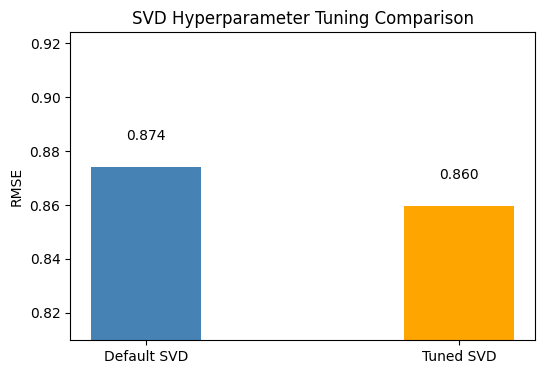

In [68]:
models = ["Default SVD", "Tuned SVD"]
rmse_values = [rmse_surprise, rmse_tuned]

plt.figure(figsize=(6,4))

bars = plt.bar(models, rmse_values, width=0.35,
               color=["steelblue", "orange"])

plt.ylabel("RMSE")
plt.title("SVD Hyperparameter Tuning Comparison")

# show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f"{height:.3f}",
             ha='center')

plt.ylim(min(rmse_values)-0.05, max(rmse_values)+0.05)

plt.show()

#Part 4 - Hybrid Recommendation Model

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

In [70]:
movie_popularity = ratings.groupby('movieId')['rating'].mean()

In [71]:
user_bias = ratings.groupby('userId')['rating'].mean()

In [72]:
hybrid_data = []

for row in ratings.itertuples():

    user = row.userId
    movie = row.movieId
    rating = row.rating

    # CF score from Surprise SVD
    cf_score = model.predict(user, movie).est

    # Content-based score
    movie_idx = movies[movies['movieId'] == movie].index

    if len(movie_idx) > 0:
        cbf_score = cosine_sim[movie_idx[0]].mean()
    else:
        cbf_score = 0

    popularity = movie_popularity.get(movie, 0)
    bias = user_bias.get(user, 0)

    hybrid_data.append([
        cf_score,
        cbf_score,
        popularity,
        bias,
        rating
    ])

In [73]:
hybrid_df = pd.DataFrame(
    hybrid_data,
    columns=[
        "CF_score",
        "CBF_score",
        "movie_popularity",
        "user_bias",
        "rating"
    ]
)

hybrid_df.head()

,CF_score,CBF_score,movie_popularity,user_bias,rating
0,4.410278,0.158614,3.920930,4.366379,4.0
1,4.011300,0.229860,3.259615,4.366379,4.0
2,4.615459,0.166115,3.946078,4.366379,4.0
3,4.535539,0.094288,3.975369,4.366379,5.0
4,4.995446,0.123399,4.237745,4.366379,5.0


In [74]:
X = hybrid_df.drop("rating", axis=1)
y = hybrid_df["rating"]

In [75]:
hybrid_model = LinearRegression()

hybrid_model.fit(X, y)

LinearRegression()

In [76]:
hybrid_predictions = hybrid_model.predict(X)

In [77]:
rmse_hybrid = np.sqrt(mean_squared_error(y, hybrid_predictions))

print("Hybrid Model RMSE:", rmse_hybrid)

Hybrid Model RMSE: 0.6545165850378218


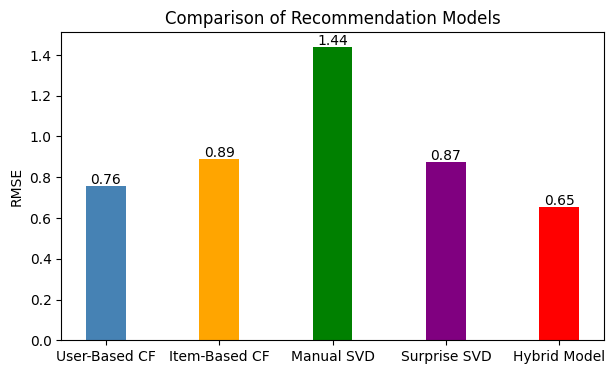

In [78]:
models = [
    "User-Based CF",
    "Item-Based CF",
    "Manual SVD",
    "Surprise SVD",
    "Hybrid Model"
]

rmse_values = [
    rmse,
    rmse_item,
    rmse_svd,
    rmse_surprise,
    rmse_hybrid
]

plt.figure(figsize=(7,4))

bars = plt.bar(models, rmse_values,
               color=["steelblue","orange","green","purple","red"],
               width=0.35)

plt.ylabel("RMSE")
plt.title("Comparison of Recommendation Models")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             height+0.01,
             f"{height:.2f}",
             ha='center')

plt.show()

#Task 8 - Content-Based Filtering with a Neural Network

In [79]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [80]:
data = ratings[['userId','movieId','rating']].copy()

In [81]:
user_ids = data['userId'].unique()
movie_ids = data['movieId'].unique()

user_to_index = {x:i for i,x in enumerate(user_ids)}
movie_to_index = {x:i for i,x in enumerate(movie_ids)}

data['user'] = data['userId'].map(user_to_index)
data['movie'] = data['movieId'].map(movie_to_index)

In [82]:
X_user = data['user'].values
X_movie = data['movie'].values
y = data['rating'].values

In [83]:
X_user_train, X_user_test, X_movie_train, X_movie_test, y_train, y_test = train_test_split(
    X_user,
    X_movie,
    y,
    test_size=0.2,
    random_state=42
)

In [84]:
num_users = len(user_ids)
num_movies = len(movie_ids)

user_input = Input(shape=(1,))
movie_input = Input(shape=(1,))

In [85]:
user_embedding = Embedding(num_users, 50)(user_input)
user_vec = Flatten()(user_embedding)

In [86]:
movie_embedding = Embedding(num_movies, 50)(movie_input)
movie_vec = Flatten()(movie_embedding)

In [87]:
combined = Concatenate()([user_vec, movie_vec])

In [88]:
dense1 = Dense(128, activation='relu')(combined)
drop1 = Dropout(0.3)(dense1)

dense2 = Dense(64, activation='relu')(drop1)
output = Dense(1)(dense2)

In [89]:
nn_model = Model(inputs=[user_input, movie_input], outputs=output)

nn_model.compile(
    optimizer='adam',
    loss='mse'
)

nn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     30,500 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    486,200 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 537,949 (2.05 MB)

 Trainable params: 537,949 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [91]:
history = nn_model.fit(
    [X_user_train, X_movie_train],
    y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 2.2112 - val_loss: 0.8127
Epoch 2/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7708 - val_loss: 0.7951
Epoch 3/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7266 - val_loss: 0.7849
Epoch 4/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6960 - val_loss: 0.7894
Epoch 5/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6757 - val_loss: 0.8000
Epoch 6/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6469 - val_loss: 0.7888


In [92]:
predictions = nn_model.predict([X_user_test, X_movie_test])

631/631 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [93]:
rmse_nn = np.sqrt(mean_squared_error(y_test, predictions))

print("Neural Network RMSE:", rmse_nn)

Neural Network RMSE: 0.8891922322711149


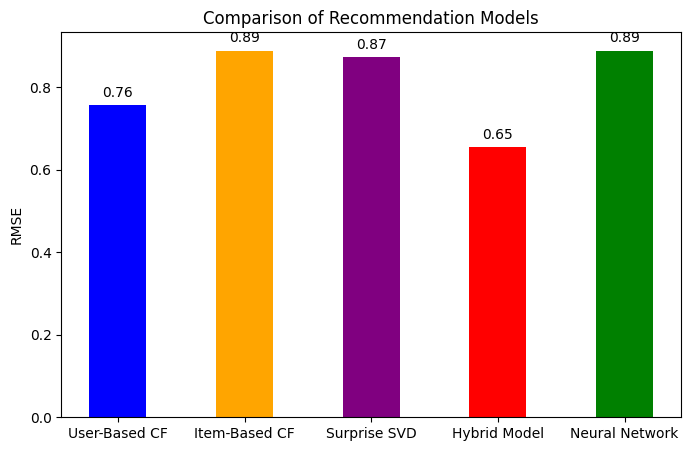

In [94]:
models = [
    "User-Based CF",
    "Item-Based CF",
    "Surprise SVD",
    "Hybrid Model",
    "Neural Network"
]

rmse_values = [
    rmse,
    rmse_item,
    rmse_surprise,
    rmse_hybrid,
    rmse_nn
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, rmse_values,
               color=["blue","orange","purple","red","green"],
               width=0.45)

plt.ylabel("RMSE")
plt.title("Comparison of Recommendation Models")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             height+0.02,
             f"{height:.2f}",
             ha='center')

plt.show()

#Task 9 - Reinforcement Learning Recommender

In [95]:
import random
import numpy as np

In [96]:
epsilon = 0.1   # exploration probability

movies_list = ratings['movieId'].unique()

# initialize rewards
movie_rewards = {movie: 0 for movie in movies_list}
movie_counts = {movie: 0 for movie in movies_list}

In [97]:
def get_reward(user, movie):

    user_data = ratings[
        (ratings['userId'] == user) &
        (ratings['movieId'] == movie)
    ]

    if len(user_data) > 0:
        rating = user_data['rating'].values[0]

        if rating >= 4:
            return 1
        else:
            return -1

    return 0

In [98]:
def choose_movie():

    if random.uniform(0,1) < epsilon:
        return random.choice(movies_list)   # explore

    else:
        return max(movie_rewards, key=movie_rewards.get)  # exploit

In [99]:
for _ in range(5000):

    user = random.choice(ratings['userId'].unique())

    movie = choose_movie()

    reward = get_reward(user, movie)

    movie_counts[movie] += 1

    # update average reward
    movie_rewards[movie] += (reward - movie_rewards[movie]) / movie_counts[movie]

In [100]:
top_movies = sorted(movie_rewards.items(), key=lambda x: x[1], reverse=True)[:5]

top_movie_ids = [m[0] for m in top_movies]

movies[movies['movieId'].isin(top_movie_ids)][['movieId','title']]

,movieId,title
0,1,Toy Story (1995)
2,3,Grumpier Old Men (1995)
5,6,Heat (1995)
1788,2387,Very Bad Things (1998)
4176,6016,City of God (Cidade de Deus) (2002)


In [101]:
alpha = 0.1   # learning rate
gamma = 0.9   # discount factor

Q = {}

for user in ratings['userId'].unique():
    Q[user] = {movie: 0 for movie in movies_list}

In [102]:
for _ in range(3000):

    user = random.choice(ratings['userId'].unique())

    # epsilon greedy action
    if random.uniform(0,1) < epsilon:
        movie = random.choice(movies_list)
    else:
        movie = max(Q[user], key=Q[user].get)

    reward = get_reward(user, movie)

    # update Q value
    Q[user][movie] = Q[user][movie] + alpha * (
        reward + gamma * max(Q[user].values()) - Q[user][movie]
    )

In [103]:
def recommend_rl(user_id, top_n=5):

    user_movies = Q[user_id]

    top_movies = sorted(user_movies.items(), key=lambda x: x[1], reverse=True)[:top_n]

    movie_ids = [m[0] for m in top_movies]

    return movies[movies['movieId'].isin(movie_ids)][['movieId','title']]

In [104]:
recommend_rl(1,5)

,movieId,title
0,1,Toy Story (1995)
2,3,Grumpier Old Men (1995)
5,6,Heat (1995)
43,47,Seven (a.k.a. Se7en) (1995)
46,50,"Usual Suspects, The (1995)"


#Task 10- Feature-Based Explanation(CBF)

In [106]:
def explain_content_based(movie_id):

    movie = movies[movies['movieId'] == movie_id].iloc[0]

    genres = movie['genres']

    print(f"Recommended because it belongs to genres: {genres}")

In [107]:
explain_content_based(top_movie_ids[0])

Recommended because it belongs to genres: Adventure Animation Children Comedy Fantasy


In [108]:
def explain_cf(movie_id):

    similar_movies = item_similarity_df[movie_id].sort_values(ascending=False)[1:6]

    print("Similar movies that influenced recommendation:")
    print(movies[movies['movieId'].isin(similar_movies.index)][['title']])

In [109]:
explain_cf(top_movie_ids[0])

Similar movies that influenced recommendation:
                                          title
224   Star Wars: Episode IV - A New Hope (1977)
314                         Forrest Gump (1994)
418                        Jurassic Park (1993)
615        Independence Day (a.k.a. ID4) (1996)
2355                         Toy Story 2 (1999)


In [110]:
def explain_nn(user_id, movie_id):

    print(f"Prediction is based on learned embeddings of user {user_id} and movie {movie_id}")
    print("Model captures hidden patterns in user preferences and movie features.")

In [111]:
explain_nn(1, top_movie_ids[0])

Prediction is based on learned embeddings of user 1 and movie 1
Model captures hidden patterns in user preferences and movie features.
